In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1e2, 1e2, 1e2], dtype=float)




In [2]:
import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

gray = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))


In [3]:
weight=None
filter_type = 'gaussian'
arepo_length = snap.length.uq
filter_length = 10*arepo_length

In [4]:
orientation = pa.Orientation(normal_vector=[1,-2,1], 
                            perp_vector1=[0,0.2,-0.3])

In [5]:
# when using the iterative filter we need to make sure that the particles required are
# loaded on the GPU. This can be achieved by increasing the search_radius
# to be larger than the maximum filter_radius of the iterative loop
# sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=None, 
#                         search_radius=20.*filter_length.value)

sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=orientation, 
                        search_radius=None)

Attempting to get derived variable: 0_Volume...	[DONE]



In [6]:
sf.gpu_variables['pos']

array([[-2.27376392e+05,  8.35204258e+05, -2.18839034e+02],
       [-2.27367351e+05,  8.35204603e+05, -2.18792382e+02],
       [-2.27361028e+05,  8.35205022e+05, -2.18776124e+02],
       ...,
       [-2.27163175e+05,  8.35463160e+05,  3.87094392e+01],
       [-2.27153617e+05,  8.35462429e+05,  3.90162545e+01],
       [-2.27147703e+05,  8.35462417e+05,  3.91728037e+01]])

In [7]:
sf.gpu_variables['center']

array([-2.27247003e+05,  8.35333662e+05, -8.96487730e+01])

In [8]:
sf.tile._pos

array([[128.40113977, 130.07626403, 131.30488603],
       [130.16379452, 130.36539109, 132.28965977],
       [129.88266624, 128.95247943, 131.95782937],
       ...,
       [210.96212079, 183.21032313, 203.05926901],
       [219.04858122, 185.49414701, 216.67142395],
       [210.26812764, 183.80524341, 199.27147165]])

In [9]:
sf.tile.tile_index.shape

(905850, 3)

In [10]:
sf.tile.off_sets

array([-2.27377374e+05,  8.35203291e+05, -2.20019694e+02])

In [11]:
sf.tile.sort_index.shape

(905850,)

In [12]:
sf.tile.unsort_index

array([447785, 447786, 447787, ..., 750699, 795057, 737270])

In [13]:
sf.tile.tile_index

array([[  0,   0,   0],
       [  4,   0,   0],
       [  8,   0,   0],
       ...,
       [105, 127, 127],
       [109, 127, 127],
       [112, 127, 127]])

In [14]:
filt_vec = sf.filter_variable(snap['0_Velocities'], filter_length, 
                                  weight=snap['0_Density'],  filter_type=filter_type, 
                                  iterative=False, selection=None)

In [15]:
filt_vec.shape

(905850, 3)

In [16]:
filt_vec

<PaicosQuantity [[-244.89814189,  -17.76335197,  489.5946174 ],
                 [-237.82874201,  -38.99867942,  477.76877534],
                 [-231.04762233,  -21.96411665,  481.46988639],
                 ...,
                 [   0.        ,    0.        ,    0.        ],
                 [   0.        ,    0.        ,    0.        ],
                 [   0.        ,    0.        ,    0.        ]] arepo_velocity small_a(1/2)>

In [17]:
# filt_den = sf.filter_variable(snap['0_Density'], filter_length, weight=None,  
#                               filter_type=filter_type, iterative=False, optimized=True, 
#                               selection=None)

In [18]:
smooth_den, turb_den = tc.extract_turbulent_var(snap, sf, '0_Density', 
                                                   filter_length=filter_length, 
                                              weight=weight, filter_type=filter_type)

min/max/avg occupancy cartesian tiling 0 / 5 / 0.43


In [19]:
smooth_den.shape

(120358394,)

In [20]:
snap['0_Coordinates'].shape

(120358394, 3)

In [21]:
widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, orientation, npix=2048)
extent = slicer.centered_extent.to('Mpc')

In [22]:
dens_tot = slicer.slice_variable('0_Density')
dens_bulk = slicer.slice_variable(smooth_den)
dens_turb = slicer.slice_variable(turb_den)

Text(0.5, 0.95, 'Density field (orientation)')

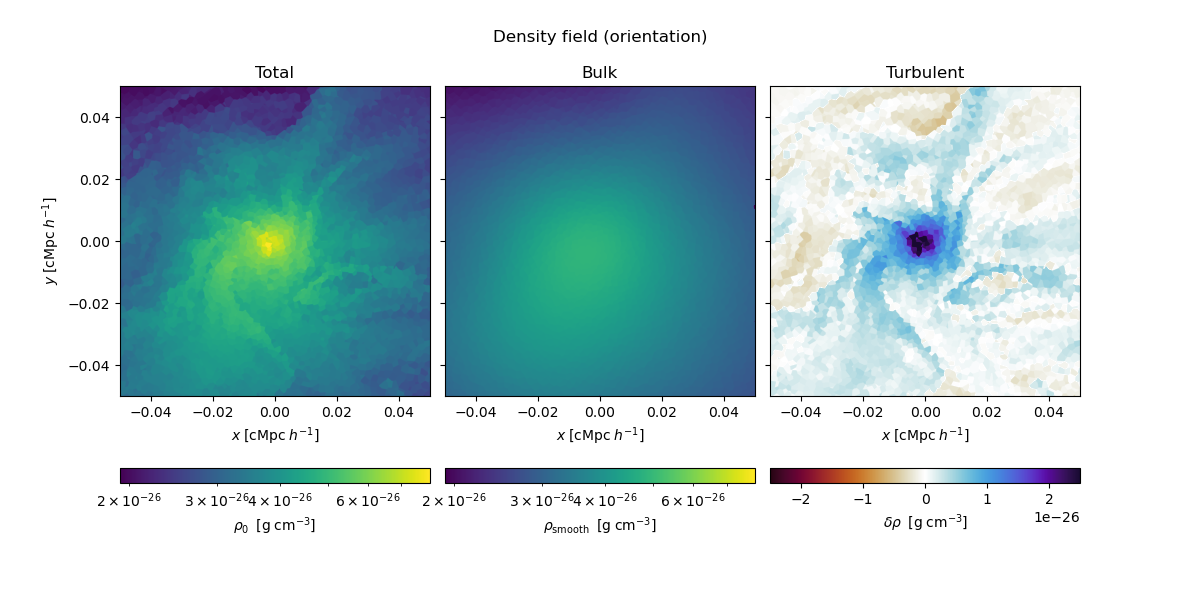

In [23]:

dens_tot = dens_tot.to_physical.cgs
dens_bulk = dens_bulk.to_physical.cgs
dens_turb = dens_turb.to_physical.cgs

vmin = np.min(dens_tot.value)
vmax = np.max(dens_tot.value)
norm = LogNorm(vmin=vmin,vmax=vmax)


vmin = -0.8*dens_turb.value.max()
vmax = 0.8*dens_turb.value.max()
norm1 = Normalize(vmin=vmin,vmax=vmax)
cmap = cmr.fusion

fig, axes = plt.subplots(1,3, figsize=(12,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_tot.value, origin='lower', norm=norm,extent=extent.value)
im2 = axes[1].imshow(
    dens_bulk.value, origin='lower', norm=norm,extent=extent.value)
im3 = axes[2].imshow(
    dens_turb.value, origin='lower', norm=norm1,cmap=cmap,extent=extent.value)

axes[0].set_title('Total')
axes[1].set_title('Bulk')
axes[2].set_title('Turbulent')

for i in range(3):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_0'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_{\mathrm{smooth}}'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(dens_tot.label('\\delta \\rho '))



fig.subplots_adjust(top=0.9,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field (orientation)',y=0.95)
# plt.savefig('../plots/density_field.pdf')

In [24]:
deriv_dens = sf.derivative_variable('0_Density', filter_length, weight=weight, 
                                       filter_type="gaussian", selection=None)

In [25]:
deriv_dens.shape

(905850, 3)

In [26]:
deriv_vec = sf.derivative_variable(snap['0_Velocities'], filter_length, weight=weight, 
                                       filter_type="gaussian", selection=None)

In [27]:
deriv_vec.shape

(905850, 3, 3)

In [28]:
grad_vel = tc.extract_derivative_var(snap, sf, snap['0_Velocities'], filter_length, 
                                     filter_type="gaussian", 
                                     selection=None)

min/max/avg occupancy cartesian tiling 0 / 5 / 0.43


In [29]:
grad_vel.shape

(120358394, 3, 3)

In [30]:
shear_matrix = tc.compute_shear_matrix(snap, sf, snap['0_Velocities'],  filter_length, 
                               filter_type,  weight='0_Density',
                               recycle=False, snap_out=None, selection=None)

min/max/avg occupancy cartesian tiling 0 / 5 / 0.43
min/max/avg occupancy cartesian tiling 0 / 5 / 0.43
min/max/avg occupancy cartesian tiling 0 / 5 / 0.43
min/max/avg occupancy cartesian tiling 0 / 5 / 0.43


In [31]:
shear_matrix

<PaicosQuantity [[[ -7.63858552,  -8.80988756,  23.43088266],
                  [-12.42421249, -10.36749831,   2.87793872],
                  [ -7.82961851,  -2.77601365,  -0.42877062]],

                 [[ -6.58933894,  -8.14659632,  24.31534261],
                  [-11.06649617, -10.04245658,   2.92697921],
                  [ -7.32449942,  -3.07399346,  -0.03037595]],

                 [[ -7.11517136,  -7.93074171,  23.5197055 ],
                  [-11.07714666, -10.2991666 ,   1.94182645],
                  [ -7.39133086,  -2.88621645,   0.25028685]],

                 ...,

                 [[  0.        ,   0.        ,   0.        ],
                  [  0.        ,   0.        ,   0.        ],
                  [  0.        ,   0.        ,   0.        ]],

                 [[  0.        ,   0.        ,   0.        ],
                  [  0.        ,   0.        ,   0.        ],
                  [  0.        ,   0.        ,   0.        ]],

                 [[  0.        ,   0.